### **Preprocessing Module**

In [12]:
import cv2
import numpy as np
from scipy.optimize import linear_sum_assignment
import os
import sys
import argparse
from collections import deque
import matplotlib.pyplot as plt

class Preprocessor:
    def __init__(self, config):
        self.config = config
    
    def process(self, frame):
        """Preprocess input frame for better detection and tracking"""
        # Resize frame
        frame = cv2.resize(frame, (self.config['resize_width'], self.config['resize_height']))
        
        # Apply Gaussian blur to reduce noise
        blurred = cv2.GaussianBlur(
            frame, 
            self.config['gaussian_blur_kernel'], 
            0
        )
        
        return blurred

### **Background Subtraction Module**

In [3]:
# 2. Background Subtraction Module
class BackgroundSubtractor:
    def __init__(self, config):
        self.config = config
        
        # Initialize background subtractor (MOG2)
        self.bg_subtractor = cv2.createBackgroundSubtractorMOG2(
            history=self.config['bg_history'],
            varThreshold=self.config['bg_threshold'],
            detectShadows=self.config['bg_detect_shadows']
        )
    
    def apply(self, frame):
        """Apply background subtraction to extract foreground mask"""
        # Apply background subtraction
        fg_mask = self.bg_subtractor.apply(frame)
        
        # Remove shadows (convert gray (127) to black (0))
        if self.config['bg_detect_shadows']:
            _, fg_mask = cv2.threshold(fg_mask, 128, 255, cv2.THRESH_BINARY)
        
        # Apply morphological operations to clean up the mask
        fg_mask = cv2.erode(fg_mask, self.config['erosion_kernel'], iterations=1)
        fg_mask = cv2.dilate(fg_mask, self.config['dilation_kernel'], iterations=2)
        
        return fg_mask


### **Object Detection Module**

In [4]:
# 3. Object Detection Module
class ObjectDetector:
    def __init__(self, config):
        self.config = config
    
    def detect(self, frame, foreground_mask):
        """Detect objects from foreground mask using contour analysis"""
        # Find contours in the foreground mask
        contours, _ = cv2.findContours(
            foreground_mask, 
            cv2.RETR_EXTERNAL, 
            cv2.CHAIN_APPROX_SIMPLE
        )
        
        # Filter contours by area and extract bounding boxes
        detections = []
        for contour in contours:
            area = cv2.contourArea(contour)
            
            if area > self.config['min_contour_area']:
                x, y, w, h = cv2.boundingRect(contour)
                confidence = min(1.0, area / 10000)  # Normalize confidence based on area
                
                if confidence >= self.config['min_detection_confidence']:
                    centroid = (int(x + w/2), int(y + h/2))
                    detections.append({
                        'bbox': (x, y, w, h),
                        'centroid': centroid,
                        'area': area,
                        'confidence': confidence,
                        'contour': contour
                    })
        
        return detections

### **Feature Extraction Module**

In [5]:
class FeatureExtractor:
    def __init__(self, config):
        self.config = config
    
    def extract(self, frame, detections):
        """Extract features for each detection"""
        features = []
        
        for detection in detections:
            x, y, w, h = detection['bbox']
            
            # Extract ROI
            roi = frame[y:y+h, x:x+w]
            if roi.size == 0:
                # Skip empty ROIs
                features.append(None)
                continue
            
            # Calculate color histogram
            hsv_roi = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
            hist_h = cv2.calcHist([hsv_roi], [0], None, [self.config['histogram_bins']], [0, 180])
            hist_s = cv2.calcHist([hsv_roi], [1], None, [self.config['histogram_bins']], [0, 256])
            
            # Normalize histograms
            cv2.normalize(hist_h, hist_h, 0, 1, cv2.NORM_MINMAX)
            cv2.normalize(hist_s, hist_s, 0, 1, cv2.NORM_MINMAX)
            
            # Compute shape features
            aspect_ratio = float(w) / h if h > 0 else 1.0
            
            # Create feature descriptor
            feature = {
                'hist_h': hist_h,
                'hist_s': hist_s,
                'aspect_ratio': aspect_ratio,
                'area': detection['area'],
                'bbox': detection['bbox']
            }
            
            features.append(feature)
        
        return features

### **Object Tracking Module with Kalman Filter**

In [6]:
# 5. Object Tracking Module with Kalman Filter
class Track:
    """Class to represent each track with its Kalman filter"""
    count = 0  # Class variable to assign unique IDs
    
    def __init__(self, detection, feature, config):
        # Assign unique ID to this track
        self.id = Track.count
        Track.count += 1
        
        # Store config
        self.config = config
        
        # Extract initial position
        x, y, w, h = detection['bbox']
        centroid_x, centroid_y = detection['centroid']
        
        # Initialize track properties
        self.bbox = detection['bbox']
        self.centroid = detection['centroid']
        self.feature = feature
        self.hits = 1          # Number of times this track was matched to a detection
        self.age = 0           # Number of frames since this track was first detected
        self.time_since_update = 0  # Number of frames since last measurement update
        self.state = 'tentative'  # Can be 'tentative', 'confirmed', or 'deleted'
        
        # For visualization
        self.color = (
            np.random.randint(0, 256),
            np.random.randint(0, 256),
            np.random.randint(0, 256)
        )
        self.trajectory = deque(maxlen=config['track_history_length'])
        self.trajectory.append(self.centroid)
        
        # Initialize Kalman filter
        self.kf = cv2.KalmanFilter(8, 4)  # 8 state variables, 4 measurement variables
        
        # State: [x, y, w, h, vx, vy, vw, vh]
        # where (x,y) is the centroid, (w,h) is the width and height,
        # and (vx,vy,vw,vh) are the respective velocities
        
        # State transition matrix
        self.kf.transitionMatrix = np.array([
            [1, 0, 0, 0, 1, 0, 0, 0],  # x = x + vx
            [0, 1, 0, 0, 0, 1, 0, 0],  # y = y + vy
            [0, 0, 1, 0, 0, 0, 1, 0],  # w = w + vw
            [0, 0, 0, 1, 0, 0, 0, 1],  # h = h + vh
            [0, 0, 0, 0, 1, 0, 0, 0],  # vx = vx
            [0, 0, 0, 0, 0, 1, 0, 0],  # vy = vy
            [0, 0, 0, 0, 0, 0, 1, 0],  # vw = vw
            [0, 0, 0, 0, 0, 0, 0, 1]   # vh = vh
        ], dtype=np.float32)
        
        # Measurement matrix (we only measure x, y, w, h)
        self.kf.measurementMatrix = np.array([
            [1, 0, 0, 0, 0, 0, 0, 0],
            [0, 1, 0, 0, 0, 0, 0, 0],
            [0, 0, 1, 0, 0, 0, 0, 0],
            [0, 0, 0, 1, 0, 0, 0, 0]
        ], dtype=np.float32)
        
        # Process noise covariance
        self.kf.processNoiseCov = np.eye(8, dtype=np.float32) * 0.03
        
        # Measurement noise covariance
        self.kf.measurementNoiseCov = np.eye(4, dtype=np.float32) * 1.0
        
        # Error covariance
        self.kf.errorCovPost = np.eye(8, dtype=np.float32) * 10.0
        
        # Initialize state
        self.kf.statePost = np.array([
            [centroid_x],          # x
            [centroid_y],          # y
            [w],                   # width
            [h],                   # height
            [0],                   # velocity x
            [0],                   # velocity y
            [0],                   # velocity width
            [0]                    # velocity height
        ], dtype=np.float32)
    
    def predict(self):
        """Predict next state using Kalman filter"""
        prediction = self.kf.predict()
        
        # Update track properties based on prediction
        cx = prediction[0, 0]
        cy = prediction[1, 0]
        w = prediction[2, 0]
        h = prediction[3, 0]
        
        # Ensure width and height are positive
        w = max(10, w)
        h = max(10, h)
        
        # Update bounding box
        x = int(cx - w/2)
        y = int(cy - h/2)
        self.bbox = (int(x), int(y), int(w), int(h))
        self.centroid = (int(cx), int(cy))
        
        # Update track properties
        self.age += 1
        self.time_since_update += 1
        
        return self.bbox, self.centroid
    
    def update(self, detection, feature):
        """Update track with new detection"""
        x, y, w, h = detection['bbox']
        centroid_x, centroid_y = detection['centroid']
        
        # Create measurement vector
        measurement = np.array([
            [centroid_x], 
            [centroid_y], 
            [w], 
            [h]
        ], dtype=np.float32)
        
        # Update Kalman filter
        self.kf.correct(measurement)
        
        # Update track properties
        self.bbox = detection['bbox']
        self.centroid = detection['centroid']
        self.feature = feature
        self.hits += 1
        self.time_since_update = 0
        
        # Update trajectory
        self.trajectory.append(self.centroid)
        
        # Update track state
        if self.state == 'tentative' and self.hits >= self.config['min_hits_for_track']:
            self.state = 'confirmed'


class Tracker:
    def __init__(self, config):
        self.config = config
        self.tracks = []
        self.frame_count = 0
    
    def _compute_cost_matrix(self, detections, features):
        """Compute cost matrix for Hungarian assignment"""
        num_tracks = len(self.tracks)
        num_detections = len(detections)
        
        if num_tracks == 0 or num_detections == 0:
            return np.zeros((0, 0))
        
        cost_matrix = np.zeros((num_tracks, num_detections))
        
        for i, track in enumerate(self.tracks):
            for j, (detection, feature) in enumerate(zip(detections, features)):
                if feature is None:
                    # Skip invalid features
                    cost_matrix[i, j] = float('inf')
                    continue
                
                # Position cost (euclidean distance between centroids)
                track_cx, track_cy = track.centroid
                det_cx, det_cy = detection['centroid']
                position_dist = np.sqrt((track_cx - det_cx)**2 + (track_cy - det_cy)**2)
                
                # Feature similarity cost
                if track.feature is None:
                    feature_cost = 0
                else:
                    # Histogram similarity (Bhattacharyya distance)
                    h1 = track.feature['hist_h']
                    h2 = feature['hist_h']
                    s1 = track.feature['hist_s']
                    s2 = feature['hist_s']
                    
                    hist_h_dist = cv2.compareHist(h1, h2, cv2.HISTCMP_BHATTACHARYYA)
                    hist_s_dist = cv2.compareHist(s1, s2, cv2.HISTCMP_BHATTACHARYYA)
                    
                    # Size similarity
                    track_w, track_h = track.bbox[2], track.bbox[3]
                    det_w, det_h = detection['bbox'][2], detection['bbox'][3]
                    
                    size_ratio_w = max(track_w, det_w) / max(1, min(track_w, det_w))
                    size_ratio_h = max(track_h, det_h) / max(1, min(track_h, det_h))
                    size_cost = (size_ratio_w + size_ratio_h) / 2.0
                    
                    # Combine costs
                    feature_cost = (hist_h_dist + hist_s_dist) / 2.0 + 0.2 * size_cost
                
                # Final cost is a weighted combination
                cost_matrix[i, j] = 0.7 * position_dist + 0.3 * feature_cost * 100
                
                # If distance is too large, make assignment impossible
                if position_dist > self.config['max_association_distance']:
                    cost_matrix[i, j] = float('inf')
        
        return cost_matrix
    
    def update(self, detections, features):
        """Update tracks with new detections"""
        self.frame_count += 1
        
        # Predict new locations of existing tracks
        for track in self.tracks:
            track.predict()
        
        # If no detections, just update track states and return
        if len(detections) == 0:
            for track in self.tracks:
                # Mark tracks for deletion if too old
                if track.time_since_update > self.config['max_frames_to_skip']:
                    track.state = 'deleted'
            
            # Remove deleted tracks
            self.tracks = [t for t in self.tracks if t.state != 'deleted']
            return self.tracks
        
        # Compute assignment cost matrix
        cost_matrix = self._compute_cost_matrix(detections, features)
        
        # Run Hungarian algorithm for assignment
        matched_tracks = []
        matched_detections = []
        
        if cost_matrix.size > 0:
            # Check if there are any non-infinite costs
            if np.isfinite(cost_matrix).any():
                # Create a copy of the cost matrix with infinite values replaced
                # by a very large number for the Hungarian algorithm
                working_cost_matrix = np.copy(cost_matrix)
                
                # Replace inf and nan values with a large finite number
                mask = ~np.isfinite(working_cost_matrix)
                working_cost_matrix[mask] = 1e10
                
                # Ensure there are no NaN values left
                if np.isnan(working_cost_matrix).any():
                    working_cost_matrix = np.nan_to_num(working_cost_matrix, nan=1e10)
                
                # Run Hungarian algorithm
                track_indices, detection_indices = linear_sum_assignment(working_cost_matrix)
                
                # Filter out assignments with infinite original cost
                for t, d in zip(track_indices, detection_indices):
                    if np.isfinite(cost_matrix[t, d]):
                        matched_tracks.append(t)
                        matched_detections.append(d)
                        
                        # Update matched track
                        self.tracks[t].update(detections[d], features[d])
        
        # Find unmatched tracks and detections
        unmatched_tracks = [i for i in range(len(self.tracks)) if i not in matched_tracks]
        unmatched_detections = [i for i in range(len(detections)) if i not in matched_detections]
        
        # Update track states for unmatched tracks
        for i in unmatched_tracks:
            self.tracks[i].time_since_update += 1
            
            # Mark for deletion if too old
            if self.tracks[i].time_since_update > self.config['max_frames_to_skip']:
                self.tracks[i].state = 'deleted'
        
        # Create new tracks for unmatched detections
        for i in unmatched_detections:
            if features[i] is not None:  # Only create if we have valid features
                new_track = Track(detections[i], features[i], self.config)
                self.tracks.append(new_track)
        
        # Remove deleted tracks
        self.tracks = [t for t in self.tracks if t.state != 'deleted']
        
        return self.tracks

### **Visualization Module**

In [7]:
# 6. Visualization Module
class Visualizer:
    def __init__(self, config):
        self.config = config
    
    def draw(self, frame, detections, tracks):
        """Draw detections, tracks, and additional visualization"""
        # Create a copy for visualization
        vis_frame = frame.copy()
        
        # Draw detections
        if self.config['show_detections']:
            for detection in detections:
                x, y, w, h = detection['bbox']
                confidence = detection['confidence']
                
                # Draw bounding box
                cv2.rectangle(
                    vis_frame, 
                    (x, y), 
                    (x + w, y + h), 
                    (0, 255, 0), 
                    2
                )
                
                # Draw confidence text
                cv2.putText(
                    vis_frame,
                    f"Conf: {confidence:.2f}",
                    (x, y - 5),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5,
                    (0, 255, 0),
                    1
                )
        
        # Draw tracks
        if self.config['show_tracks']:
            for track in tracks:
                if track.state == 'confirmed':
                    x, y, w, h = track.bbox
                    
                    # Draw bounding box
                    cv2.rectangle(
                        vis_frame, 
                        (x, y), 
                        (x + w, y + h), 
                        track.color, 
                        2
                    )
                    
                    # Draw ID
                    cv2.putText(
                        vis_frame,
                        f"ID: {track.id}",
                        (x, y - 10),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.5,
                        track.color,
                        2
                    )
                    
                    # Draw trajectory
                    for i in range(1, len(track.trajectory)):
                        if track.trajectory[i - 1] is None or track.trajectory[i] is None:
                            continue
                        
                        cv2.line(
                            vis_frame,
                            track.trajectory[i - 1],
                            track.trajectory[i],
                            track.color,
                            2
                        )
        
        return vis_frame

### **Main Class**

In [ ]:
# Main class that integrates all components
class MultipleObjectTracker:
    def __init__(self, config=None):
        # Default configuration
        self.config = {
            # Preprocessing parameters
            'resize_width': 640,
            'resize_height': 480,
            'gaussian_blur_kernel': (5, 5),
            
            # Background subtraction parameters
            'bg_history': 500,
            'bg_threshold': 16,
            'bg_detect_shadows': True,
            
            # Object detection parameters
            'min_contour_area': 500,
            'erosion_kernel': np.ones((3, 3), np.uint8),
            'dilation_kernel': np.ones((5, 5), np.uint8),
            
            # Feature extraction parameters
            'histogram_bins': 16,
            
            # Tracking parameters
            'max_association_distance': 100,
            'max_frames_to_skip': 10,
            'min_detection_confidence': 0.5,
            
            # Track management parameters
            'min_hits_for_track': 3,
            'max_age_for_track': 30,
            
            # Visualization parameters
            'show_detections': True,
            'show_tracks': True,
            'track_history_length': 20,
        }
        
        # Update with user-provided configuration if available
        if config:
            self.config.update(config)
        
        # Initialize components
        self.preprocessor = Preprocessor(self.config)
        self.background_subtractor = BackgroundSubtractor(self.config)
        self.object_detector = ObjectDetector(self.config)
        self.feature_extractor = FeatureExtractor(self.config)
        self.tracker = Tracker(self.config)
        self.visualizer = Visualizer(self.config)
        
        self.frame_count = 0
    
    def process_frame(self, frame):
        self.frame_count += 1
        
        # Run the full pipeline
        processed_frame = self.preprocessor.process(frame)
        foreground_mask = self.background_subtractor.apply(processed_frame)
        detections = self.object_detector.detect(processed_frame, foreground_mask)
        features = self.feature_extractor.extract(processed_frame, detections)
        tracks = self.tracker.update(detections, features)
        visualized_frame = self.visualizer.draw(processed_frame, detections, tracks)
        
        return visualized_frame, detections, tracks
    
    def process_video(self, video_path, output_path=None):
        cap = cv2.VideoCapture(video_path)
        
        if not cap.isOpened():
            print(f"Error: Could not open video {video_path}")
            return
        
        # Get video properties
        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        fps = cap.get(cv2.CAP_PROP_FPS)
        frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        
        # Setup output video writer if needed
        if output_path:
            fourcc = cv2.VideoWriter_fourcc(*'XVID')
            out = cv2.VideoWriter(output_path, fourcc, fps, (self.config['resize_width'], self.config['resize_height']))
        
        processing_stats = {
            'frame_count': 0,
            'tracked_objects': []
        }
        
        while True:
            ret, frame = cap.read()
            
            if not ret:
                break
            
            processed_frame, detections, tracks = self.process_frame(frame)
            processing_stats['frame_count'] += 1
            processing_stats['tracked_objects'].append(len(tracks))
            
            # Display result
            cv2.imshow("Multiple Object Tracking", processed_frame)
            
            # Write to output file if specified
            if output_path:
                out.write(processed_frame)
            
            # Break on ESC key
            if cv2.waitKey(1) & 0xFF == 27:  # ESC key
                break
        
        # Cleanup
        cap.release()
        if output_path:
            out.release()
        cv2.destroyAllWindows()
        
        return processing_stats

### **Run Tracker**

Processed 407 frames
Average tracked objects per frame: 3.32


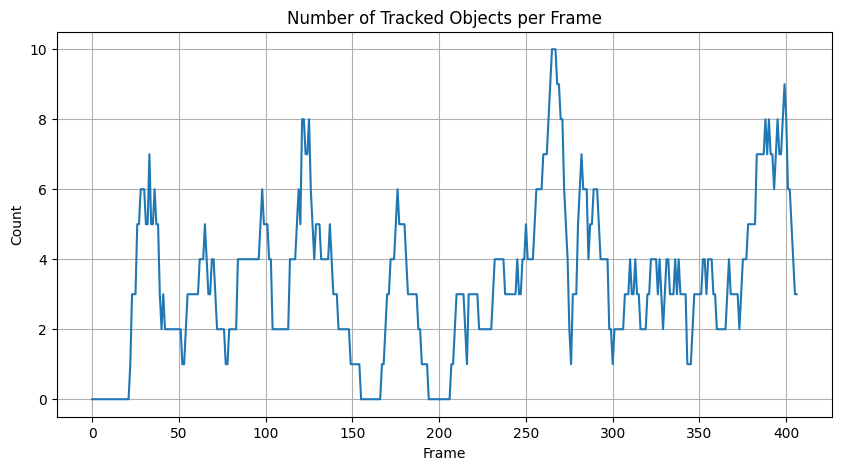

In [11]:
def run_tracker(input_video_path, output_video_path='output_video.avi'):
    """
    Run the Multiple Object Tracker on a video file
    
    Args:
        input_video_path (str): Path to the input video file
        output_video_path (str, optional): Path to save the output video. If None, the output is not saved.
        
    Returns:
        dict: Statistics about the tracking process
    """
    # Create tracker with default configuration
    tracker = MultipleObjectTracker()
    
    # Process video
    stats = tracker.process_video(input_video_path, output_video_path)
    
    # Print statistics
    print(f"Processed {stats['frame_count']} frames")
    print(f"Average tracked objects per frame: {np.mean(stats['tracked_objects']):.2f}")
    
    # Plot number of tracked objects over time
    plt.figure(figsize=(10, 5))
    plt.plot(stats['tracked_objects'])
    plt.title('Number of Tracked Objects per Frame')
    plt.xlabel('Frame')
    plt.ylabel('Count')
    plt.grid(True)
    plt.savefig('tracking_stats.png')
    plt.show()
    
    return stats


# Example usage
if __name__ == "__main__":
    # Check if video file exists first
    video_path = "video2.mp4"  # Replace with your actual video path
    
    if not os.path.exists(video_path):
        print(f"Error: Video file '{video_path}' not found.")
        print("Please provide a valid video file path or use command line arguments.")
        
        # Check if we're running with command line arguments
        if len(sys.argv) > 1:
            parser = argparse.ArgumentParser(description='Multiple Object Tracking')
            parser.add_argument('--input', type=str, required=True, help='Path to input video')
            parser.add_argument('--output', type=str, default=None, help='Path to output video')
            args = parser.parse_args()
            
            if os.path.exists(args.input):
                run_tracker(args.input, args.output)
            else:
                print(f"Error: Video file '{args.input}' not found.")
    else:
        # Run the tracker with default video path
        output_path = "output_video.mp4"  # Set to a path if you want to save output
        run_tracker(video_path, output_path)